In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from PIL import Image
import matplotlib.pyplot as plt 

In [ ]:
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])

MNIST_test = datasets.MNIST(root='data', train=False, download=True)
MNIST_train = datasets.MNIST(root='data', train=True, download=True)

100.0%
100.0%
100.0%
100.0%


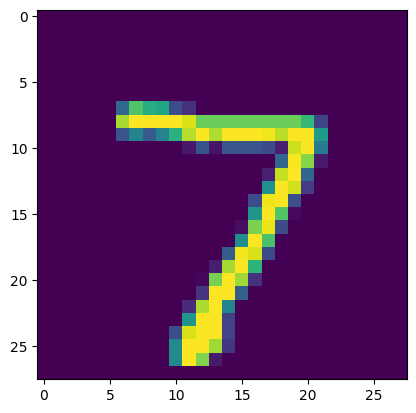

In [5]:
plt.imshow(MNIST_test[0][0])

In [8]:
test_loader = torch.utils.data.DataLoader(dataset=MNIST_test, batch_size=1000)
train_loader = torch.utils.data.DataLoader(dataset=MNIST_train, batch_size=64)

In [11]:
class NN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5)
    self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5)
    self.fc1 = nn.Linear(6400, 128)
    self.fc2 = nn.Linear(128, 10)
  
  def forward(self, x):                # input (1, 28, 28)
    x = self.conv1(x)                  # batch (32, 24, 24)
    x = F.relu(x)
    x = self.conv2(x)                  # batch (64, 20, 20)
    x = F.relu(x)
    x = F.max_pool2d(x, kernel_size=2) # batch (64, 10, 10)
    x = torch.flatten(x, start_dim=1)  # batch (6400)
    x = self.fc1(x)                    # batch (128)
    x = self.fc2(x)                    # batch (10)
    return F.log_softmax(x, dim=1)


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = NN().to(device)
optimizer = torch.optim.Adadelta(model.parameters())

In [25]:
def train():
  model.train()
  for batch_idx, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)
    optimizer.zero_grad()
    output = model(data)
    loss = F.nll_loss(output, target)
    loss.backward()
    optimizer.step()

In [21]:
def test():
  model.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for data, target in test_loader:
      data, target = data.to(device), target.to(device)
      output = model(data)
      test_loss += F.nll_loss(output, target, reduction='sum').item()
      pred = output.argmax(dim=1, keepdim=True)
      correct += pred.eq(target.view_as(pred)).sum().item()
      
  test_loss /= len(test_loader.dataset)

  print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
      test_loss, correct, len(test_loader.dataset),
      100. * correct / len(test_loader.dataset)))

In [27]:
def main():
  epochs = 30
  for epoch in range(epochs):
    train()
  test()

In [28]:
main()

TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'PIL.Image.Image'>